Saving 3.jpg to 3 (1).jpg


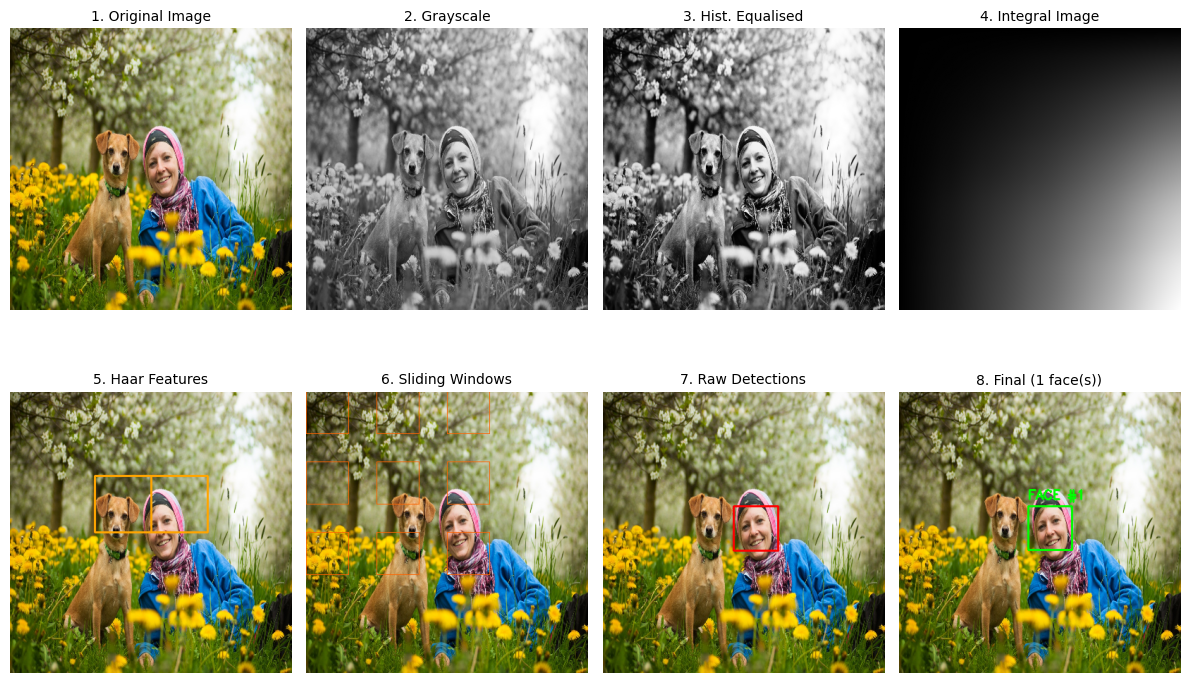

Raw detections: 1
Final detections: 1


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize for better visualization
img = cv2.resize(img, (400, 400))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. Original
# 2. Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Histogram Equalization
gray_eq = cv2.equalizeHist(gray)

# 4. Integral Image
integral_img = cv2.integral(gray_eq)

# Normalize for display
integral_display = cv2.normalize(integral_img, None, 0, 255, cv2.NORM_MINMAX)
integral_display = integral_display.astype(np.uint8)

# 5. Haar Feature Visualization (dummy rectangles)
haar_img = img_rgb.copy()
cv2.rectangle(haar_img, (120, 120), (200, 200), (255, 165, 0), 2)
cv2.rectangle(haar_img, (200, 120), (280, 200), (255, 165, 0), 2)

# 6. Sliding Windows
sliding_img = img_rgb.copy()
for x in range(0, 300, 100):
    for y in range(0, 300, 100):
        cv2.rectangle(sliding_img, (x, y), (x+60, y+60), (255, 100, 0), 1)

# 7. Raw Detections
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_alt2.xml'
)

faces_raw = face_cascade.detectMultiScale(gray_eq, 1.05, 3)

raw_img = img_rgb.copy()
for (x, y, w, h) in faces_raw:
    cv2.rectangle(raw_img, (x, y), (x+w, y+h), (255, 0, 0), 2)

# 8. Final Detection
faces_final = face_cascade.detectMultiScale(gray_eq, 1.1, 5)

final_img = img_rgb.copy()
for i, (x, y, w, h) in enumerate(faces_final):
    cv2.rectangle(final_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(final_img, f"FACE #{i+1}", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

# ----------- Plot All -----------
titles = [
    "1. Original Image",
    "2. Grayscale",
    "3. Hist. Equalised",
    "4. Integral Image",
    "5. Haar Features",
    "6. Sliding Windows",
    "7. Raw Detections",
    f"8. Final ({len(faces_final)} face(s))"
]

images = [
    img_rgb,
    gray,
    gray_eq,
    integral_display,
    haar_img,
    sliding_img,
    raw_img,
    final_img
]

plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2, 4, i+1)
    if i in [1,2,3]:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])
    plt.title(titles[i], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Raw detections:", len(faces_raw))
print("Final detections:", len(faces_final))